# FP ablation pretraining

Local comparison of runs from the `fp_ablation_pretrain` experiment. The tables use the last logged value for each metric. The curves use the complete MLflow metric history and the global `step`.

Run the notebook from the repository root. Total loss and FP loss are excluded from the main comparison because they change directly with the ablation.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
candidates = [Path('results/ablation/fp_ablation_pretrain'), Path('fp_ablation_pretrain'), Path('../fp_ablation_pretrain')]
results_dir = next(path for path in candidates if (path / 'runs.csv').exists())
runs = pd.read_csv(results_dir / 'runs.csv')
history = pd.read_csv(results_dir / 'metric_history.csv')
last = pd.read_csv(results_dir / 'last_metrics.csv')
print(f'{len(runs)} runs, {len(history)} metric points')
runs[['run_name', 'status', 'script_scope', 'start_time_utc', 'duration_minutes']]

5 runs, 52029 metric points


,run_name,status,script_scope,start_time_utc,duration_minutes
0,fp-ablation-pretrain-no-fp,FINISHED,script_run,2026-09-01T14:08:05.366000+00:00,279.57
1,fp-ablation-pretrain-weighted-fp,FINISHED,script_run,2026-09-01T18:47:47.512000+00:00,276.00
2,fp-ablation-pretrain-balanced-fp,FINISHED,script_run,2026-09-01T23:23:56.259000+00:00,253.68
3,fp-ablation-pretrain-balanced-fp-0.2-lambda,FAILED,extra_run_in_experiment,2026-09-02T12:15:30.613000+00:00,276.89
4,fp-ablation-pretrain-morgan-bits,FINISHED,extra_run_in_experiment,2026-09-04T11:36:37.364000+00:00,320.38


## Final table

`script_run` identifies the three configurations launched by the shell script. Any `extra_run_in_experiment` runs are kept and explicitly marked.

In [2]:
columns = [
    'run_name', 'status', 'script_scope', 'param_lambda_fp',
    'param_balanced_fp_pairs', 'param_fingerprint_objective',
    'train_shift_loss', 'val_shift_loss',
    'val_h_shift_mae_ppm', 'val_c_shift_mae_ppm',
    'probe_maccs_macro_auroc', 'val_fp_mae', 'val_fp_macro_mae',
    'duration_minutes', 'gpu_peak_allocated_mb', 'gpu_peak_reserved_mb',
]
columns = [column for column in columns if column in last.columns]
final_table = last[columns].copy()
metric_columns = [column for column in columns if column not in {'run_name', 'status', 'script_scope', 'param_lambda_fp', 'param_balanced_fp_pairs', 'param_fingerprint_objective'}]
final_table[metric_columns] = final_table[metric_columns].apply(pd.to_numeric, errors='coerce').round(4)
final_table

,run_name,status,script_scope,param_lambda_fp,param_balanced_fp_pairs,param_fingerprint_objective,train_shift_loss,val_shift_loss,val_h_shift_mae_ppm,val_c_shift_mae_ppm,probe_maccs_macro_auroc,val_fp_mae,val_fp_macro_mae,duration_minutes,gpu_peak_allocated_mb,gpu_peak_reserved_mb
0,fp-ablation-pretrain-no-fp,FINISHED,script_run,0.0,False,NaN,5.0512,5.2413,1.1682,21.1573,0.7806,0.0733,0.2005,279.57,96013.7812,106128.0
1,fp-ablation-pretrain-weighted-fp,FINISHED,script_run,0.1,False,NaN,5.0604,5.2407,1.1662,21.0497,0.7859,0.0130,0.2102,276.00,96013.7734,106128.0
2,fp-ablation-pretrain-balanced-fp,FINISHED,script_run,0.1,True,NaN,5.1552,5.2422,1.1640,21.2097,0.7965,0.0263,0.1479,253.68,67241.4062,76384.0
3,fp-ablation-pretrain-balanced-fp-0.2-lambda,FAILED,extra_run_in_experiment,0.2,True,NaN,5.1429,5.2705,1.1808,22.0356,0.8048,0.0233,0.1252,276.89,67241.1484,76382.0
4,fp-ablation-pretrain-morgan-bits,FINISHED,extra_run_in_experiment,0.1,False,bits,5.1420,5.2416,1.1643,21.1618,0.7916,NaN,NaN,320.38,67252.7578,73594.0


## Learning curves

The main curves measure peak semantics (`shift`) and the probe. H/C MAE is a validation metric when available. Learning rate is included as context for interpreting short runs.

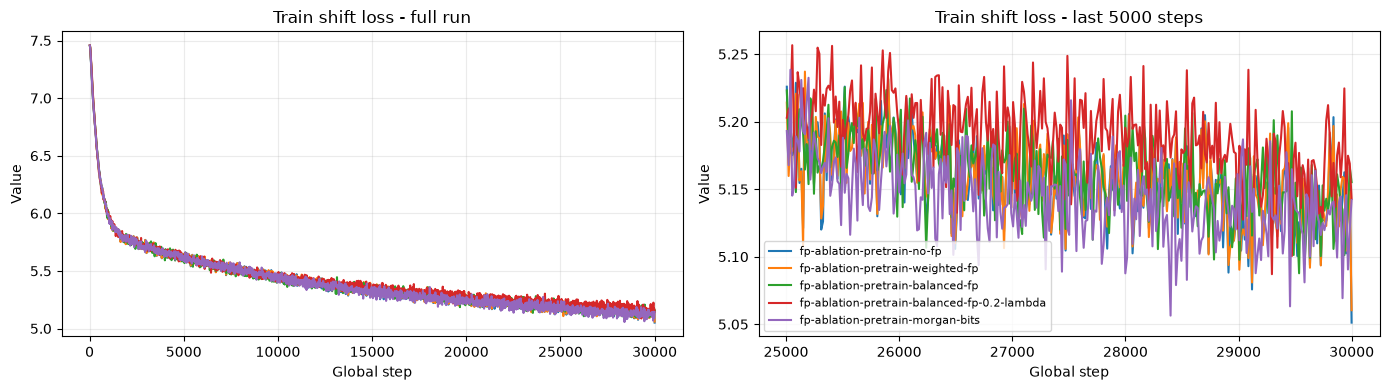

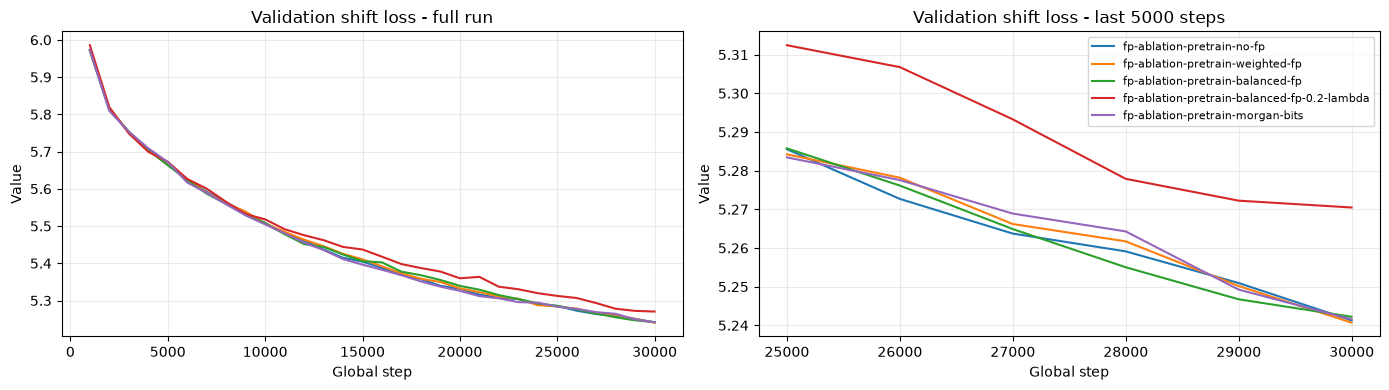

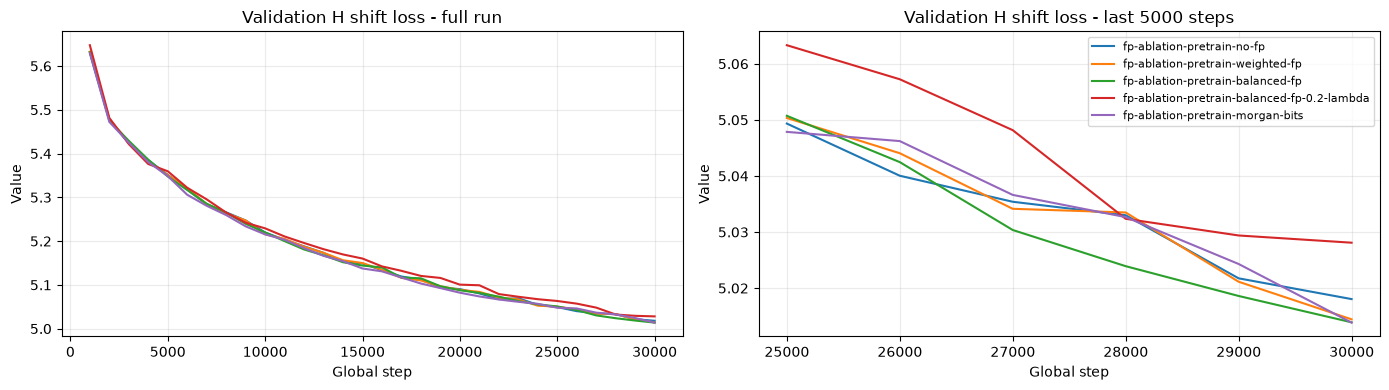

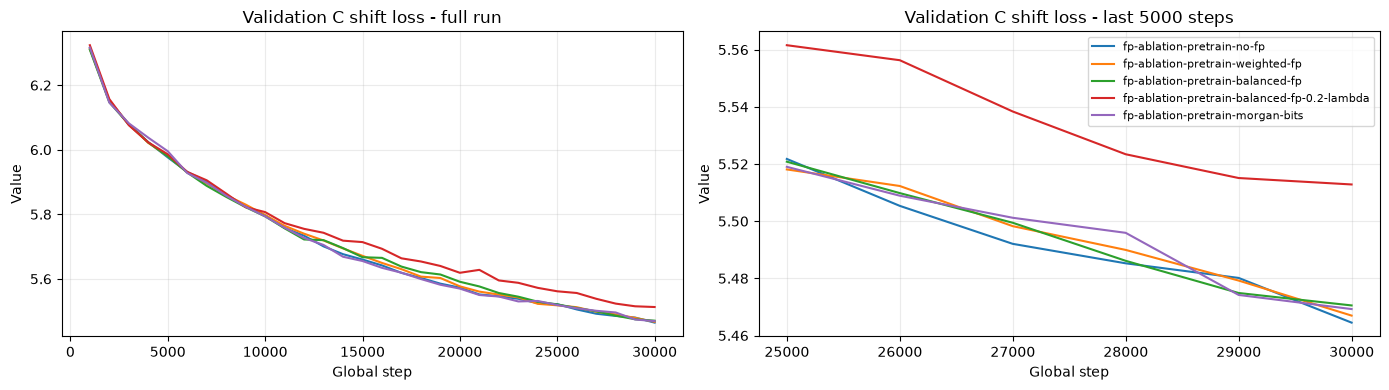

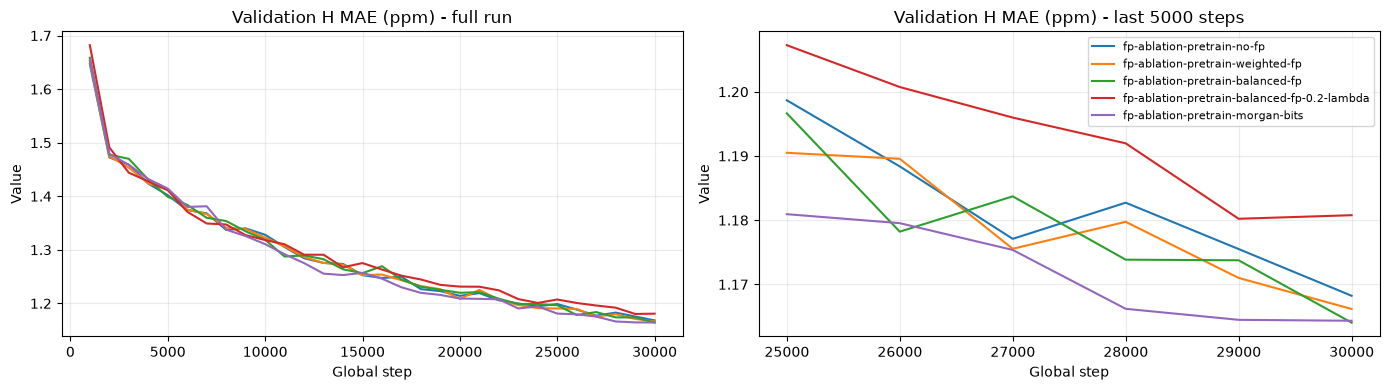

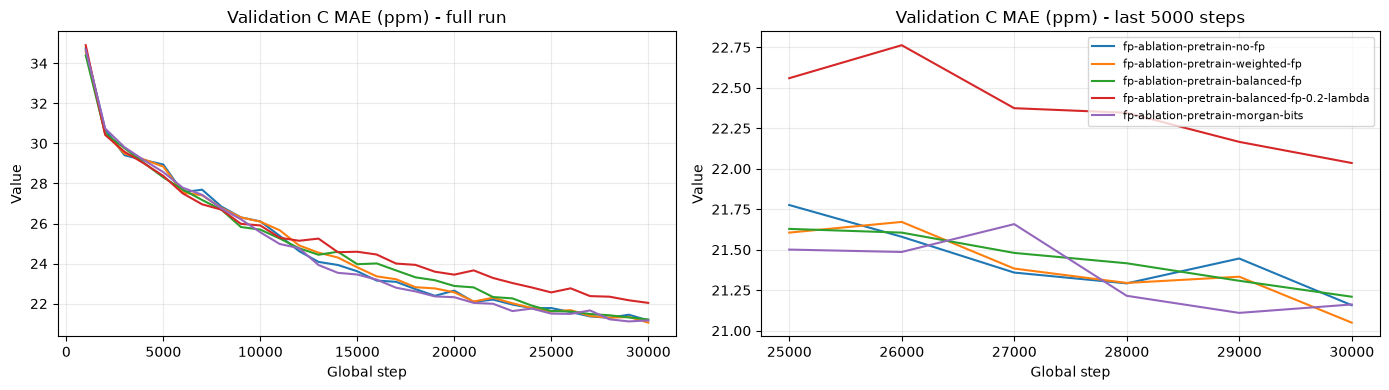

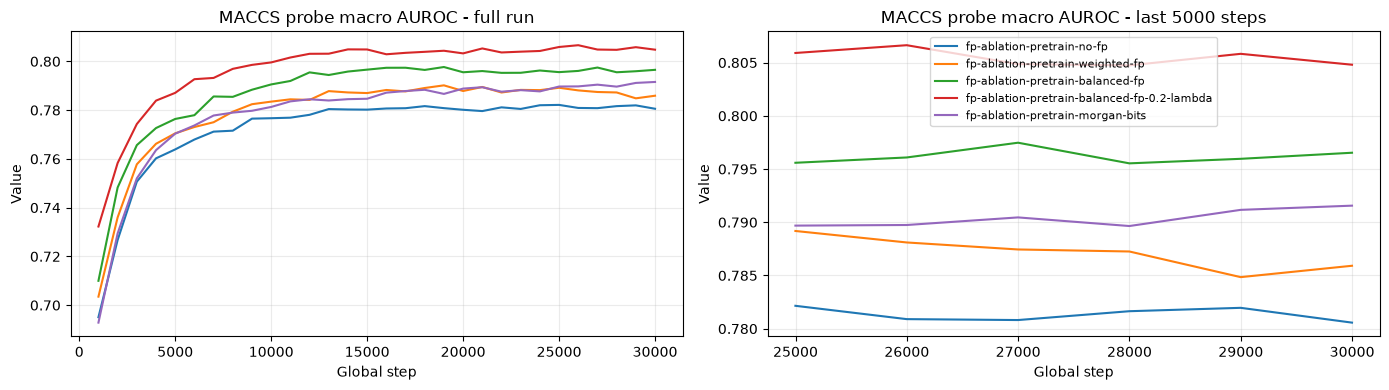

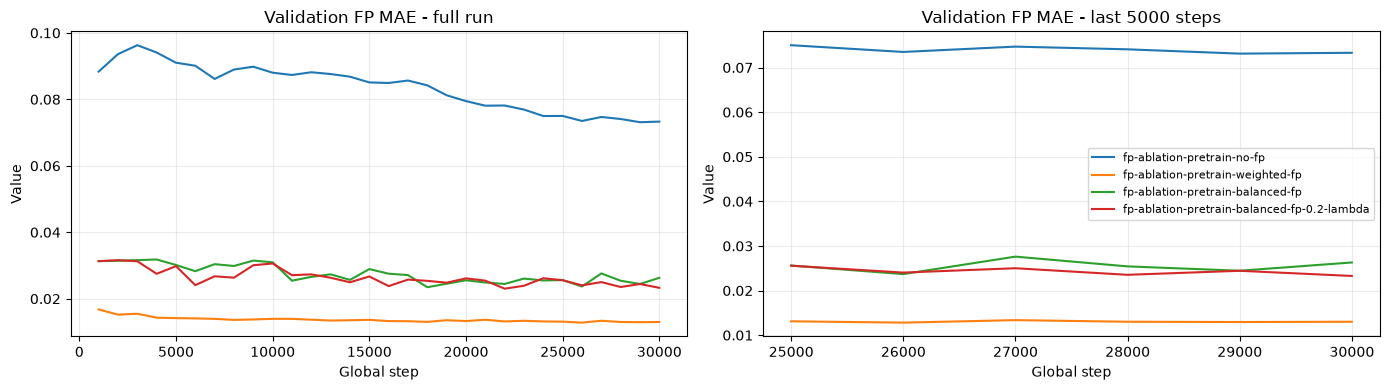

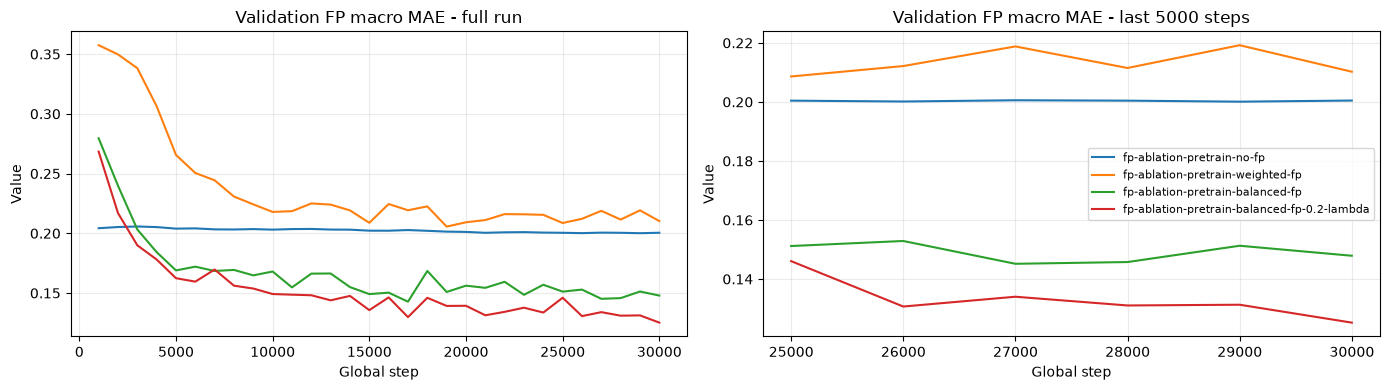

train/rich: not logged in this experiment
val/annotation: not logged in this experiment


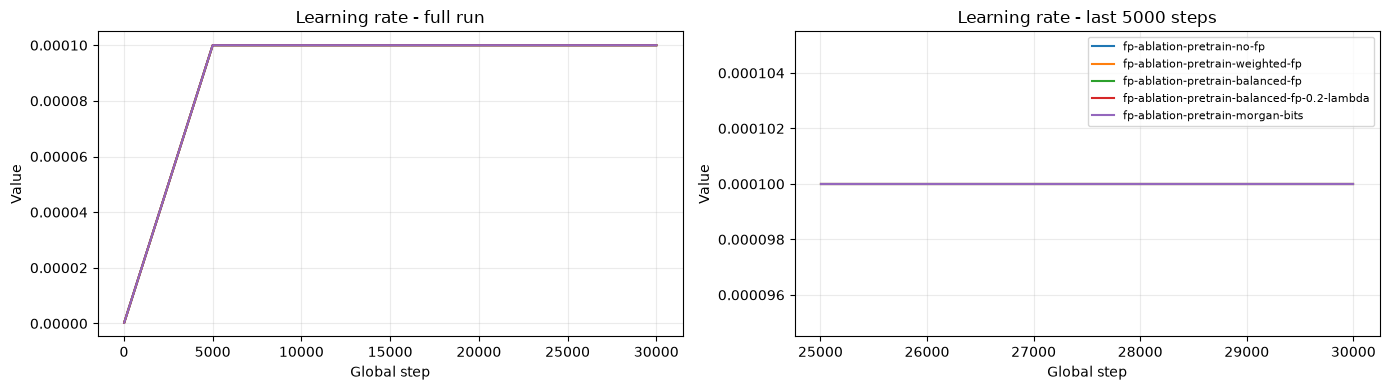

In [3]:
plot_metrics = {
    "train/shift": "Train shift loss",
    "val/shift": "Validation shift loss",
    "val/shift_h": "Validation H shift loss",
    "val/shift_c": "Validation C shift loss",
    "val/shift/h_mae_ppm": "Validation H MAE (ppm)",
    "val/shift/c_mae_ppm": "Validation C MAE (ppm)",
    "probe/maccs_macro_auroc": "MACCS probe macro AUROC",
    "val/fp_mae": "Validation FP MAE",
    "val/fp_macro_mae": "Validation FP macro MAE",
    "train/rich": "Train annotation rich loss",
    "val/annotation": "Validation annotation rich loss",
    "lr-AdamW": "Learning rate",
}

run_names = history["run_name"].drop_duplicates().tolist()
colors = plt.get_cmap("tab10").colors
run_colors = {name: colors[index % len(colors)] for index, name in enumerate(run_names)}

def plot_metric(metric, title, n_steps=5000):
    data = history[history["metric"] == metric].copy()
    if data.empty:
        print(f"{metric}: not logged in this experiment")
        return

    last_step = data["step"].max()
    closeup = data[data["step"] >= last_step - n_steps].copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

    for run_name, group in data.groupby("run_name", sort=False):
        group = group.sort_values("step")
        axes[0].plot(group["step"], group["value"], label=run_name, color=run_colors[run_name])
    for run_name, group in closeup.groupby("run_name", sort=False):
        group = group.sort_values("step")
        axes[1].plot(group["step"], group["value"], label=run_name, color=run_colors[run_name])

    axes[0].set_title(f"{title} - full run")
    axes[1].set_title(f"{title} - last {n_steps} steps")
    for axis in axes:
        axis.set(xlabel="Global step", ylabel="Value")
        axis.grid(alpha=0.25)
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

for metric, title in plot_metrics.items():
    plot_metric(metric, title)

## Resources and initial interpretation

GPU memory was logged once at the end of each run. `duration_minutes` is computed from MLflow timestamps; no explicit execution-time or throughput metric was logged.

In [4]:
resource_columns = [
    'run_name', 'status', 'script_scope', 'duration_minutes',
    'gpu_peak_allocated_mb', 'gpu_peak_reserved_mb',
]
resources = last[resource_columns].copy()
resources.iloc[:, 3:] = resources.iloc[:, 3:].apply(pd.to_numeric, errors='coerce').round(2)
resources

,run_name,status,script_scope,duration_minutes,gpu_peak_allocated_mb,gpu_peak_reserved_mb
0,fp-ablation-pretrain-no-fp,FINISHED,script_run,279.57,96013.78,106128.0
1,fp-ablation-pretrain-weighted-fp,FINISHED,script_run,276.00,96013.77,106128.0
2,fp-ablation-pretrain-balanced-fp,FINISHED,script_run,253.68,67241.41,76384.0
3,fp-ablation-pretrain-balanced-fp-0.2-lambda,FAILED,extra_run_in_experiment,276.89,67241.15,76382.0
4,fp-ablation-pretrain-morgan-bits,FINISHED,extra_run_in_experiment,320.38,67252.76,73594.0


For a quantitative conclusion, focus on the final `val/shift`, the H/C MAE values, and the probe, while also considering the shape of the curves. Since the runs are short, small differences at the final point should not be interpreted as convergence.